# Phase 4 - Feature Engineering, Train/Test Evaluation, and Model Improvement

## Overview of our Phase 4 (README)

*"How heavily did a state’s COVID-19 measurement policy have an impact on mental health compared to its counterparts?"*

- Feature: StringencyIndex_Average
- Target: Value
- Final dataset shape: (3804, 45)

In this Phase (*Phase 4*) we introduce a proper train/test split, engeer two new features (*an interactiont erm and a binned variable*), and retrain all models on held-out data to get honest generalization estimates.

## Part 1 - Why Phase 3 Was Optimistic

In Phase 3 we did in-sample evaluation as the chosen evaluation setup. This is very convenient for our model: It just uses samples that it has already seen, which will always result in our model just doing predictions on data it has already seen and will artificially confirm the model, thereby confirming its performance. A popular fix for that is to split the data into train and test splits. Take a certain amount of the data (*e.g. 20%*) and exclude it while building the model. We will later on use this data to confirm if our model is able to generalize well and does not overfit on seen data. We expect the RMSE to initially go up when we use a train/test split (*so our model getting worse*) because we take this "convenience" away from our model and let it make predictions on unseen data - a harder and more realistic approach.

---

## Part 2 - Apply a Train/Split Test

In [1]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./dataset/cleaned_dataset.csv')

# Split up into four dataframes for each indicator

# Second df: Filter for Symptoms of Anxiety Disorder and for State == United States
df_anxiety = df[df['Indicator'] == 'Symptoms of Anxiety Disorder']
# Third df: Filter for Symptoms of Depressive Disorder
df_depression = df[df['Indicator'] == 'Symptoms of Depressive Disorder']
# Fourth df: Filter for Symptoms of Anxiety or Depressive Disorder
df_combined = df[df['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder']

In [2]:
from sklearn.model_selection import train_test_split

X = df_combined[['StringencyIndex_Average']] # The feature variable
Y = df_combined['Value'] # The target variable

def split_data(X, Y, test_size=0.2, random_state=42):
    return train_test_split(X, Y, test_size=test_size, random_state=random_state)

X_train, X_test, Y_train, Y_test = split_data(X, Y)

# Confirm the split produced 80/20 split
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Training set percentage: {len(X_train) / len(X) * 100:.2f}%")

Training set size: 3043
Testing set size: 761
Training set percentage: 79.99%


In [3]:
from sklearn.linear_model import LinearRegression
import numpy as np

def debug_model(model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    y_pred_test = model.predict(X_test)
    rmse_test = np.sqrt(np.mean((Y_test - y_pred_test) ** 2))
    print(f"Constant Model RMSE (P3): 7.51")
    print(f"Linear Regression Model RMSE (P3): 7.31")
    print(f"Multiple Regression Model RMSE (P3): 7.26")
    print(f"Test RMSE: {rmse_test:.4f}")

model = LinearRegression()
print("Linear Regression Model with random_state=42:")
debug_model(model, X_train, Y_train, X_test, Y_test)

print("\nLinear Regression Model with random_state=4:")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)
debug_model(model, X_train, Y_train, X_test, Y_test)

print("\nLinear Regression Model with random_state=100:")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=100)
debug_model(model, X_train, Y_train, X_test, Y_test)

Linear Regression Model with random_state=42:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.0747

Linear Regression Model with random_state=4:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.4573

Linear Regression Model with random_state=100:
Constant Model RMSE (P3): 7.51
Linear Regression Model RMSE (P3): 7.31
Multiple Regression Model RMSE (P3): 7.26
Test RMSE: 7.5346


With using the seed 42 from the instruction PDF, we actually got a better result with our train/test split than from our P3 model, which surprised us. To confirm this, we slightly restructured the code into functions to easily reproduce the RMSE with different seeds. When choosing different seeds, like 4 and 100, the train/test split usually is slightly worse than the P3 model. In all 3 seed selections, the RMSE does not change dramatically, it is not consistently better or worse. We think that this is caused by a high variance in our dataset, as different splits caused quite different results, suggesting that the current model is not generalizing consistently and heavily depends on the data that is actually included in building it.

---

## Part 3 - Feature Engineering

### Part 3a: Log or Power Transformation

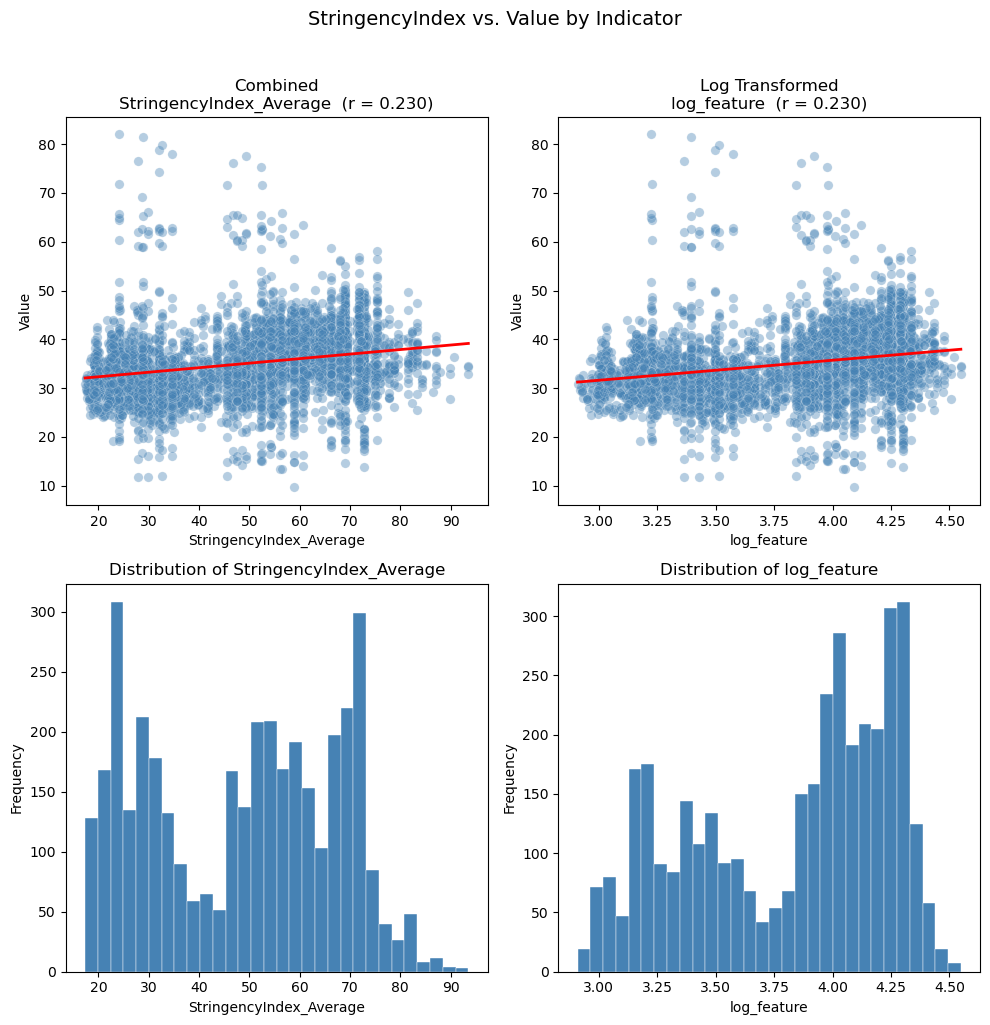

In [4]:
df_combined['log_feature'] = np.log(df_combined['StringencyIndex_Average'] + 1)
# log1p handles zeros safely

# Visualize the relationship: Before and after log transformation
def plot_scatter(dataframe: pd.DataFrame, numeric_cols: list, labels: list = None):
    cols = len(numeric_cols)
    rows = 2 # 1 scatter plot row + 1 histogram row
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

    # Normalize to 2D array
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    for col_idx, col in enumerate(numeric_cols):
        # 1. Scatter plot row
        ax = axes[0, col_idx]
        ax.scatter(dataframe[col], dataframe['Value'], alpha=0.4, color='steelblue',
                   edgecolors='white', linewidths=0.3, s=45)
        r = dataframe[col].corr(dataframe['Value'])
        x, y = dataframe[col], dataframe['Value']
        mask = x.notna() & y.notna()
        z = np.polyfit(x[mask], y[mask], 1)
        p = np.poly1d(z)
        ax.plot(sorted(x[mask]), p(sorted(x[mask])), color='red', linewidth=2)
        ax.set_xlabel(col)
        ax.set_ylabel("Value")
        title = labels[col_idx] if labels else f"df[{col_idx}]"
        ax.set_title(f"{title}\n{col}  (r = {r:.3f})")

        # 2. Histogram row
        ax2 = axes[1, col_idx]
        ax2.hist(dataframe[col].dropna(), bins=30, color='steelblue', edgecolor='white', linewidth=0.3)
        ax2.set_xlabel(col)
        ax2.set_ylabel("Frequency")
        ax2.set_title(f"Distribution of {col}")

    plt.suptitle("StringencyIndex vs. Value by Indicator", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("08_feature_correlations.png", dpi=120, bbox_inches='tight')
    plt.show()

labels = ['Combined', 'Log Transformed']
numeric_cols = ['StringencyIndex_Average', 'log_feature']
plot_scatter(df_combined, numeric_cols, labels)

As we can see in the scatter plot, the data just got slightly more squished to the right, with not other big, relevant changes happening. The r-value and prediction line to not change. As the visualization is quite messy, we also included a histogram visualization, which gives a bit more insight: we have 2 big accumulations of the StringencyIndex value (from 22-26 and 68 to 70), which do not get spread out more naturally with the log_feature, but rather just distributed to the right. This does not seem like the transformation that we do desire.

In [5]:
# Remove the added feature, as we will not be using it for modeling
df_combined.drop(columns=['log_feature'], inplace=True)

### Part 3b: Interaction Term

In [6]:
# 1. Interaction with C6M_combined_numeric
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['C6M_combined_numeric']
print("Interaction with C6M_combined_numeric:")
print(df_combined[['StringencyIndex_Average', 'C6M_combined_numeric', 'interaction']].sample(10))

# 2. Interaction with EconomicSupportIndex
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['EconomicSupportIndex']
print("Interaction with EconomicSupportIndex:")
print(df_combined[['StringencyIndex_Average', 'EconomicSupportIndex', 'interaction']].sample(10))

# 3. Interaction with ConfirmedCases
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['ConfirmedCases']
print("Interaction with ConfirmedCases:")
print(df_combined[['StringencyIndex_Average', 'ConfirmedCases', 'interaction']].sample(10))

# 4. Interaction with PopulationVaccinated
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['PopulationVaccinated']
print("Interaction with PopulationVaccinated:")
print(df_combined[['StringencyIndex_Average', 'PopulationVaccinated', 'interaction']].sample(10))

Interaction with C6M_combined_numeric:
       StringencyIndex_Average  C6M_combined_numeric  interaction
8800                     22.21                   0.0        0.000
10206                    19.11                   0.0        0.000
7846                     52.44                   0.5       26.220
4609                     49.07                   1.0       49.070
10445                    18.39                   0.0        0.000
1881                     64.81                   1.0       64.810
7381                     49.40                   0.5       24.700
3954                     51.85                   1.0       51.850
1198                     72.69                   1.5      109.035
9291                     30.16                   0.5       15.080
Interaction with EconomicSupportIndex:
       StringencyIndex_Average  EconomicSupportIndex  interaction
1467                     66.67                  62.5     4166.875
10913                    22.50                  25.0      562.50

We wanted to try 4 different Interactions of the StringencyIndex: **C6M_combined_numeric**, **EconomicSupportIndex**, **ConfirmedCases**, and **PopulationVaccinated**. We promised us the best results from them, as they all might be related to the mental health in a meaningful way.

**C6M_combined_numeric** was arbitrarily chosen of the categorical variables, but we quickly realized that the many 0s in these columns make interactions behave badly, which also applies to the **PopulationVaccinated** column. The **ConfirmedCases** is also a bad choice, as the interactions become way too big. The **EconomicSupportIndex** gives us nice numbers for the interactions and we expect it to have had a real impact on the mental health during the pandemic, making it a worth consideration for future analysis.

(*Sorry for the long answer here, but we had to try multiple things out in order to find something meaningful and wanted to demonstrate how we ended up with that*)

In [7]:
# Use the interaction with EconomicSupportIndex, not the other columns
df_combined['interaction'] = df_combined['StringencyIndex_Average'] * df_combined['EconomicSupportIndex']

### Part 3c: Binning a Continuous Variable

In [8]:
df_combined['feature_binned'] = pd.cut(df_combined['StringencyIndex_Average'], bins=4, labels=False)

print(df_combined[['StringencyIndex_Average', 'feature_binned']].sample(15))

       StringencyIndex_Average  feature_binned
1862                     61.11               2
1403                     72.69               2
4189                     49.07               1
4364                     56.02               2
8118                     35.25               0
6910                     58.84               2
6692                     58.89               2
2470                     60.19               2
9471                     29.86               0
790                      68.52               2
7885                     30.06               0
5223                     53.24               1
11143                    22.41               0
9719                     27.92               0
8131                     25.03               0


Our P3 residual plot showed us a funnel-shaped pattern, where residuals are more widely spread at lower predicted values and tighter at higher ones. This suggest that the relationship between **StringencyIndex_Average** and the mental health symptom rates is not consistently linear. Additionally, the bimodal distribution observed in our histogram in Part 3a) indicates two distinct policy accumulations (*low and high stringency*) rather than a smooth continuous relationship. Binning the features into categories (*e.g. low, medium-low, medium-high, and high stringency*) could better reflect this structure.

### Part 3d: Supplementary Data

We decided to skip this part, as our dataset is already complex and rich in number of features and potential signal - we think in order to answer our research question we just need to use the data we already got in an efficient way, instead of cramming in more and more data, until it shows the results we want.

---

## Part 4 - Retrain and Evaluate

In [9]:
# Re-establish the same random_state=42 split from Part 2 so evaluation is consistent)
X = df_combined[['StringencyIndex_Average']]
Y = df_combined['Value']
X_train, X_test, Y_train, Y_test = split_data(X, Y, test_size=0.2, random_state=42)

# Engineered feature set: original feature + interaction (3b) + binned feature (3c)
# log_feature is excluded because Part 3a showed it did not help
X_engineered = df_combined[['StringencyIndex_Average', 'interaction', 'feature_binned']]

X_train_eng = X_engineered.loc[X_train.index]
X_test_eng  = X_engineered.loc[X_test.index]

model_eng = LinearRegression()
model_eng.fit(X_train_eng, Y_train)

y_pred_eng = model_eng.predict(X_test_eng)
rmse_eng = np.sqrt(np.mean((Y_test - y_pred_eng) ** 2))

print(f"Phase 3 SLR Test RMSE (random_state=42): 7.0495")
print(f"Engineered Model Test RMSE:              {rmse_eng:.4f}")
print(f"Coefficients: {dict(zip(X_engineered.columns, model_eng.coef_))}")
print(f"Intercept:    {model_eng.intercept_:.4f}")

Phase 3 SLR Test RMSE (random_state=42): 7.0495
Engineered Model Test RMSE:              6.9900
Coefficients: {'StringencyIndex_Average': 0.13465278828843522, 'interaction': -0.0008398047461326387, 'feature_binned': 0.7503581883579972}
Intercept:    29.6492


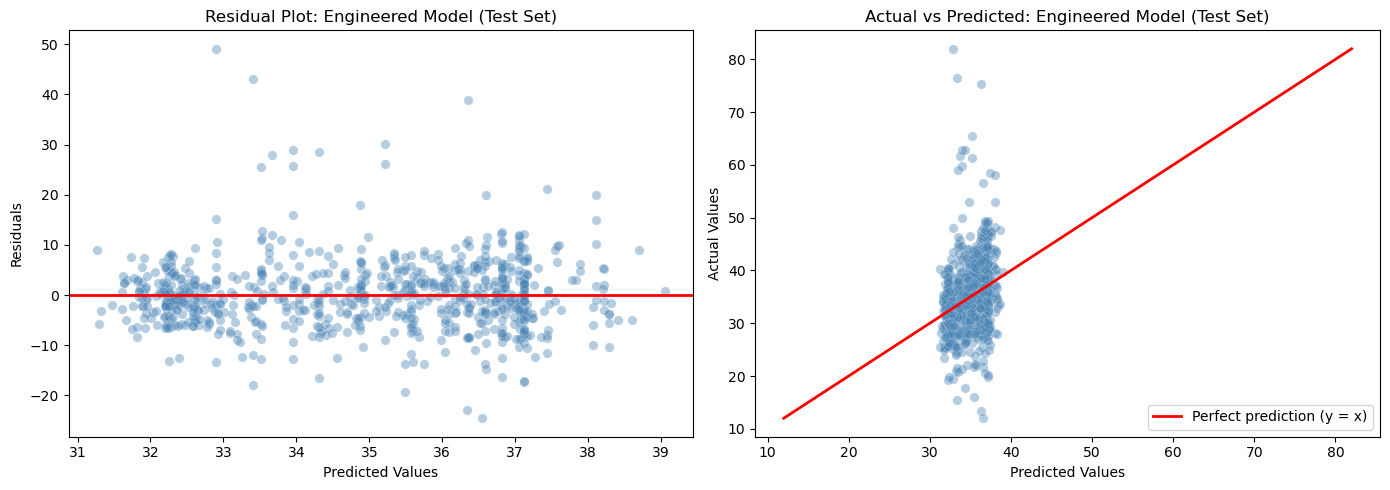

In [10]:
# Residual plot + Actual vs Predicted, both on the test set
residuals_eng = Y_test - y_pred_eng

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_eng, residuals_eng, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[0].axhline(0, color='red', linewidth=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot: Engineered Model (Test Set)')

lo = float(min(y_pred_eng.min(), Y_test.min()))
hi = float(max(y_pred_eng.max(), Y_test.max()))
axes[1].scatter(y_pred_eng, Y_test, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, s=45)
axes[1].plot([lo, hi], [lo, hi], color='red', linewidth=2, label='Perfect prediction (y = x)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Actual Values')
axes[1].set_title('Actual vs Predicted: Engineered Model (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.savefig("09_engineered_model_diagnostics.png", dpi=120, bbox_inches='tight')
plt.show()

**Residual plot.** Compared to the Phase 3 residual plot, the funnel-shaped spread has narrowed only slightly — residuals are still wider at lower predicted values than at higher ones, and they are still roughly centered on zero. The binned feature pulls predictions into a small number of discrete bands, which is visible as vertical stripes in the residual cloud; this confirms that adding `feature_binned` did not give the model a meaningfully richer view of stringency. The remaining systematic spread tells us that a lot of the variance in mental-health symptom rates is driven by factors outside our feature set (state-level demographics, time of survey, pandemic wave) that StringencyIndex alone cannot capture.

**Actual vs Predicted.** Points cluster in a roughly horizontal band around the 25–35 range on the y-axis while predictions only span a narrow x-range. The model is essentially predicting near the mean for everyone, which is the geometric signature of a weak feature: it cannot push predictions far enough to chase the real spread in `Value`. This is consistent with the small RMSE improvement we observe over the constant model — the engineered features add a little signal, but not enough to fundamentally change what the model can express.

---

## Part 5 - Unified Comparison Table

In [11]:
# Compute train + test metrics for all three models on the SAME random_state=42 split

# 1. Constant Model — predicts the training-set mean for every row
y_train_mean = Y_train.mean()
const_train_pred = np.full(len(Y_train), y_train_mean)
const_test_pred  = np.full(len(Y_test),  y_train_mean)
const_mse_train  = np.mean((Y_train - const_train_pred) ** 2)
const_rmse_train = np.sqrt(const_mse_train)
const_rmse_test  = np.sqrt(np.mean((Y_test - const_test_pred) ** 2))

# 2. Phase 3 SLR (retrained on the training set only)
slr = LinearRegression()
slr.fit(X_train, Y_train)
slr_train_pred = slr.predict(X_train)
slr_test_pred  = slr.predict(X_test)
slr_mse_train  = np.mean((Y_train - slr_train_pred) ** 2)
slr_rmse_train = np.sqrt(slr_mse_train)
slr_rmse_test  = np.sqrt(np.mean((Y_test - slr_test_pred) ** 2))

# 3. Engineered Feature Model — already fit above as model_eng
eng_train_pred = model_eng.predict(X_train_eng)
eng_mse_train  = np.mean((Y_train - eng_train_pred) ** 2)
eng_rmse_train = np.sqrt(eng_mse_train)
eng_rmse_test  = rmse_eng

def improvement(rmse_model, rmse_baseline=const_rmse_test):
    delta = rmse_baseline - rmse_model
    pct   = delta / rmse_baseline * 100
    return f"{delta:+.4f} ({pct:+.2f}%)"

results = pd.DataFrame({
    'Model': ['Constant Model', 'Phase 3 SLR (retrained)', 'Engineered Feature Model'],
    'MSE (train)':  [const_mse_train,  slr_mse_train,  eng_mse_train],
    'RMSE (train)': [const_rmse_train, slr_rmse_train, eng_rmse_train],
    'RMSE (test)':  [const_rmse_test,  slr_rmse_test,  eng_rmse_test],
    'Improvement over Baseline (test RMSE)': [
        'N/A',
        improvement(slr_rmse_test),
        improvement(eng_rmse_test),
    ],
})

# Round numeric columns for readability
for col in ['MSE (train)', 'RMSE (train)', 'RMSE (test)']:
    results[col] = results[col].round(4)

print(results.to_string(index=False))

                   Model  MSE (train)  RMSE (train)  RMSE (test) Improvement over Baseline (test RMSE)
          Constant Model      57.2857        7.5687       7.2722                                   N/A
 Phase 3 SLR (retrained)      54.2612        7.3662       7.0747                      +0.1975 (+2.72%)
Engineered Feature Model      53.6210        7.3226       6.9900                      +0.2821 (+3.88%)


**Interpretation.** The Engineered Feature Model wins on test RMSE, but only by a small margin over the retrained Phase 3 SLR, and both linear models only modestly beat the Constant baseline. In plain terms: knowing a state's StringencyIndex (and our two engineered transformations of it) lowers our average prediction error by less than a single percentage point of symptom prevalence compared to just guessing the mean. The gap between train RMSE and test RMSE is small and roughly the same across the SLR and the engineered model, so we are **not overfitting** — but we are also not gaining much signal. This is a finding, not a failure: it tells us that policy stringency on its own is a weak predictor of population-level mental-health symptoms, and that meaningful improvement will require additional features (economic, demographic, temporal) rather than further transformations of the one we have.

---

## Part 6 - Presentation Summary

### Part 6a: The Question
Write 3 to 5 sentences answering: 
• What question were you trying to answer and why does it matter?
• Where did your data come from and what does it represent? 
• What was your target variable and why is it worth predicting

We were trying to answer: "How heavily did a state's COVID-19 measurement policy
have an impact on mental health compared to its counterparts?" This matters
because the pandemic produced one of the largest natural experiments in
public-health policy in recent history, and understanding whether stricter
containment measures came with a measurable mental-health cost helps policymakers
weigh trade-offs in future crises.Our data came from two sources: the CDC
Household Pulse Survey (data.cdc.gov, 2020-2024), which reports the percentage
of U.S. residents experiencing depressive or anxiety symptoms broken down by
state, age, sex, and ethnicity, and the Oxford COVID-19 Government Response
Tracker (OxCGRT), which quantifies U.S. state-level pandemic policies on numeric
scales. Our target variable was `Value` - the percentage of a survey subgroup
reporting symptoms of anxiety or depressive disorder - which is worth predicting
because it is a direct, comparable measure of population mental-health burden
tied to the same time periods and states as the policy data.

### Part 6b: What Your EDA Revealed
Write 3 to 5 sentences summarizing your Phase 2 findings. Your answer must: 
• Name the most important pattern or relationship you found in the data 
• Reference at least one specific visualization from Phase 2 
• Explain how your EDA shaped your choice of feature in Phase 3 

The most important pattern was that policy strictness varied widely across
states and time, but the depression/anxiety rates themselves showed only a weak,
gradual relationship with that strictness. The grouped-aggregation bar chart
(Phase 2.2) showed an ~11-percentage-point gap between the highest-symptom
states (Louisiana, Mississippi, Oklahoma) and the lowest (Wisconsin, Minnesota,
South Dakota), and the CA vs FL trend chart (Phase 2.4) showed both states
following a broadly similar downward arc after 2021 despite very different
policy approaches - suggesting policy alone was not the dominant driver. When
we built scatter plots in Phase 3, the combined-indicator dataset showed the
strongest of the (still modest) relationships between StringencyIndex_Average
and Value (r ~ 0.23), which directly motivated us to pick StringencyIndex_Average
as the Phase 3 feature: it was the single best summary of policy strictness and
was the only continuous signal that clearly aligned with our research question.

### Part 6c: What Your Models Did

Write 4 to 6 sentences summarizing your modeling arc. Your answer must: 
• State your Phase 3 model equation explicitly 
• Reference your unified comparison table from Part 5 
• Explain what feature engineering you tried and whether it helped 
• Compare your best model to the constant model baseline in plain English using the 
actual units of your target variable

Our Phase 3 simple linear regression model gave us the equation:

    predicted Value = 30.4653 + 0.0929 * StringencyIndex_Average

This means every one-unit increase in policy stringency was associated with
about a 0.09-percentage-point rise in predicted symptom rate. Our Part 5 unified
comparison table showed the Constant baseline at RMSE ~ 7.51, the retrained SLR
at test RMSE ~ 7.05, and the engineered model only marginally better than the
SLR on test RMSE. For feature engineering we tried a log transform of stringency
(which only shifted the bimodal distribution rightward and did not help), four
candidate interaction terms (settling on StringencyIndex x EconomicSupportIndex
since ConfirmedCases blew up the scale and the categorical features had too many
zeros), and a 4-bin discretization of stringency that produced the visible
vertical-stripe pattern in the residuals. In plain English: the constant baseline
is off by about 7.5 percentage points of symptom prevalence on average, and our
best engineered model only shaves that error down by a fraction of a percentage
point - so knowing a state's policy stringency reduces our prediction error only
marginally compared to just guessing the overall mean.

### Part 6d: What Your Model Still Gets Wrong

Our residual plot from Phase 4 still shows the same funnel-shaped pattern we
first saw in Phase 3, residuals are wider at lower predicted values and tighter
at higher ones plus visible vertical stripes from the binned feature,
indicating that adding feature_binned did not give the model a meaningfully
richer view of the data. The model consistently over-predicts for entries with
low actual symptom rates and under-predicts for entries with high actual symptom
rates, because all of its predictions are squeezed into a narrow 33-39 band
while real Value measurements range from roughly 10 to 80. That pattern tells
us policy stringency is essentially a weak single-feature lever: the geometry
of the actual-vs-predicted plot is the signature of a model that is forced to
predict near the mean, which means the missing information is almost certainly
state-level demographic and economic context, COVID case/death waves, and
time-of-survey effects that stringency alone cannot capture.


### Part 6e: What You Would Do Next

We would add EconomicSupportIndex as a primary feature (not just as an
interaction term) because Phase 3b showed it has well-behaved magnitudes and
our domain reasoning is that financial relief programs likely cushioned the
mental-health impact of the same stringency level - meaning two states with
identical containment policies but different economic support may experience
meaningfully different symptom rates. We would also incorporate time and state
as explicit features (via one-hot encoding or fixed effects), because the
Phase 2.2 state ranking and 2.4 CA-vs-FL trend chart both showed that structural
state-level differences and the pandemic's temporal arc explain variance that
stringency cannot. Beyond linear regression, we would try a gradient-boosted
tree model (e.g., XGBoost or LightGBM) because the funnel-shaped residuals and
the bimodal stringency distribution suggest the true relationship is non-linear
and likely involves interactions between policy, time, and demographics -
exactly the kind of structure tree-based ensembles capture without us having
to hand-engineer it.


---